# Curso: Estadística Aplicada
## Maestría en Ciencias Matemáticas
## Primavera 2024. MMTE31302

### Los códigos originalmente se encuentran escritos en Jupyter notebook, pero pueden ser ejecutados en Visual Studio o bien en Google Colab. En cada uno de ellos se explica el contexto teórico del código. 

# 5 Análisis Exploratorio de Datos (EDA)

### EDA se basa en la estadística descriptiva. El objetivo es, a través de un conjunto de datos, extraer su caracteristicas principales.

# Áreas de la estadística
## $\bf{Descriptiva:}\newline$
### Se dedica a la descripción, visualización y resumen de datos originados a partir de los fenómenos de estudio. Su objetivo es organizar y describir las características sobre un conjunto de datos con el propósito de facilitar interpretación.

## $\bf{Inferencial:}\newline$
### Se dedica a la generación de los modelos y predicciones asociadas a los fenómenos en cuestión teniendo en cuenta la aleatoriedad de las observaciones.

### $\bf{A)}$ Máxima Verosimilitud

### $\bf{B)}$ Intervalos de Confianza

### $\bf{C)}$ Prueba de Hipótesis 


# Tipos de datos
## $\bf{Cualitativo:}$

### Son las propiedades categóricas que pueden usarse para describir un ente. (Nacionalidad de una persona, tipo de fruta)

## $\bf{Cuantitativo:}$

### Representan una cantidad. Por ejemplo: presión arterial, pulsaciónes, etc.

# Tipo de variables
$\bf{Cualitativas}$ $\bf{boleanas:}$ $\newline$
### La data solo toma dos valores. Ej: Masculino/Femenino, Fumador/No-Fumador, Falso/Verdadero.

$\bf{Cualitativas}$ $\bf{nominales:}$ $\newline$
### Cuando los valores que toma la variable permiten clasificar a la población en categorías mutuamente excluyentes. Ej: Grupo sanguineo, estado civil.

$\bf{Cualitativas}$ $\bf{ordinales:}$ $\newline$
### Los valores que toma la variable pueden ser ordenados. Ejemplo: Estado de un paciente que ingresa a un hospital (leve, grave, muy grave). Cabe aclarar que estas también pueden tener una escala determinada como las notas "R","B","MB". Estas son variables cualitativas ordinales a las que se les asocia un número

$\bf{Cuantitativas}$ $\bf{discretas:}$ $\newline$
### Pueden tomar solo valores en un conjunto numerable. Ej: La cantidad de pacientes que ingresaron al hospital un día determinado. El número de clientes que ingresan a un servidor.

$\bf{Cuantitativas}$ $\bf{continuas:}$ $\newline$
### Son continuas cuando pueden tomar todos los valores de un determinado intervalo de números reales. Ejemplo: Medición de volumen, longitud, dinero, altura.

In [22]:

import pandas as pd
dfc = pd.read_csv("coaster_db.csv")

In [23]:
dfc.head(5)

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,...,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [24]:
dfc.shape #dimensiones

(1087, 56)

In [25]:
dfc.columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       'Track layout', 'Fastrack available', 'Soft opening date.1',
       'Closing date', 'Opened', 'Replaced by', 'Website',
       'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       'Single rider line available', 'Restraint Style',
       'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'height_ft',
       'Inversions_clean', 'Gforce_clean'],
      dtype='object')

In [26]:
dfc.dtypes

coaster_name                      object
Length                            object
Speed                             object
Location                          object
Status                            object
Opening date                      object
Type                              object
Manufacturer                      object
Height restriction                object
Model                             object
Height                            object
Inversions                       float64
Lift/launch system                object
Cost                              object
Trains                            object
Park section                      object
Duration                          object
Capacity                          object
G-force                           object
Designer                          object
Max vertical angle                object
Drop                              object
Soft opening date                 object
Fast Lane available               object
Replaced        

In [27]:
dfc=dfc[['coaster_name', 'Location', 'Status', 'speed2', 'height_ft', 'Gforce_clean', 'Type_Main', 'year_introduced']].copy()

In [28]:
dfc.dtypes

coaster_name        object
Location            object
Status              object
speed2              object
height_ft          float64
Gforce_clean       float64
Type_Main           object
year_introduced      int64
dtype: object

In [29]:
dfc.isna().sum() #numero de NA

coaster_name         0
Location             0
Status             213
speed2             152
height_ft          916
Gforce_clean       725
Type_Main            0
year_introduced      0
dtype: int64

In [30]:
dfc=dfc.rename(columns={'coaster_name': 'Nombre', 'Location': 'Ubicación', 
                        'Status': 'Estado', 'speed2': 'Velocidad', 'height_ft': 'Altura', 
                        'Gforce_clean': 'Fuerza_g', 'Type_Main': 'Material', 'year_introduced': 'Año'})

In [31]:
dfc.columns

Index(['Nombre', 'Ubicación', 'Estado', 'Velocidad', 'Altura', 'Fuerza_g',
       'Material', 'Año'],
      dtype='object')

### Iniciemos trabajando con la variable velocidad.

In [32]:
dfc['Velocidad']

0        9.7 km/h
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
1082      85 km/h
1083     117 km/h
1084    95.4 km/h
1085      55 km/h
1086      93 km/h
Name: Velocidad, Length: 1087, dtype: object

In [33]:
dfc['Velocidad'] =  dfc['Velocidad'].str.replace('km/h', '')

In [34]:
dfc.dtypes

Nombre        object
Ubicación     object
Estado        object
Velocidad     object
Altura       float64
Fuerza_g     float64
Material      object
Año            int64
dtype: object

In [35]:
def mph_to_kph(var):
    if isinstance(var, float):
        return var * 1.60934
    elif 'mph' in var:
        return float(var.replace(' mph', '')) * 1.60934
    elif 'km/h' in var:
        return float(var.replace(' km/h', ''))
    else:
        return float(var)

In [36]:
dfc['Velocidad'] = dfc['Velocidad'].apply(mph_to_kph)

In [37]:
dfc.dtypes

Nombre        object
Ubicación     object
Estado        object
Velocidad    float64
Altura       float64
Fuerza_g     float64
Material      object
Año            int64
dtype: object

### Ahora con la variable Altura

### Las unidades de la variable Altura son ft, realicemos la converción a metros.

In [38]:
dfc['Altura']= dfc['Altura'] * 0.3048

In [39]:
dfn=dfc[['Velocidad', 'Altura','Fuerza_g']]

In [40]:
dfn.describe()

,Velocidad,Altura,Fuerza_g
count,935.000000,171.000000,362.000000
mean,78.127165,31.088531,3.824006
std,26.836873,20.521907,0.989998
min,8.000000,3.992880,0.800000
25%,60.000000,15.788640,3.400000
50%,80.000000,27.797760,4.000000
75%,93.000000,39.989760,4.500000
max,239.952594,115.001040,12.000000


In [41]:
dfn.mean()

Velocidad    78.127165
Altura       31.088531
Fuerza_g      3.824006
dtype: float64

In [42]:
import numpy as np
data_median = np.median(dfn["Velocidad"])
data_median

np.float64(nan)

### Nota: Si decides calcular la mediana directamente sobre un conjunto de datos que contiene al menos un NaN, el resultado será NaN. Esto es porque NaN representa un valor no numérico y puede afectar la validez del cálculo de la mediana.

In [43]:
data_median =np.nanmedian(dfn["Velocidad"])
data_median

np.float64(80.0)

In [44]:
from scipy import stats
data_mode = stats.mode(dfn["Fuerza_g"])
data_mode

ModeResult(mode=np.float64(nan), count=np.int64(725))

In [45]:
stats.mode(dfn["Fuerza_g"], nan_policy='omit')

ModeResult(mode=np.float64(4.0), count=np.int64(61))

In [46]:
np.max(dfn["Fuerza_g"])

np.float64(12.0)

In [47]:
np.min(dfn["Fuerza_g"])

np.float64(0.8)

In [48]:
dfc.query('Fuerza_g == 12')

,Nombre,Ubicación,Estado,Velocidad,Altura,Fuerza_g,Material,Año
1,Flip Flap Railway,Sea Lion Park,Removed,NaN,NaN,12.0,Wood,1895


In [49]:
dfc['Estado'].value_counts()

Estado
Operating                                                         668
Removed                                                           137
Closed                                                             24
Under construction                                                 15
In Production                                                      11
Discontinued                                                        7
Closed in 2021                                                      2
SBNO December 2019                                                  2
Chapter 7 bankruptcy; rides dismantled and sold; property sold      2
closed for maintenance as of july 30 no reopening date known        1
Not Currently Operating                                             1
Temporarily Closed                                                  1
SBNO (Standing But Not Operating)                                   1
Temporarily closed                                                  1
Under Mainten

In [50]:
dfoper=dfc.query('Estado=="Operating"')

In [51]:
dfoper.head()

,Nombre,Ubicación,Estado,Velocidad,Altura,Fuerza_g,Material,Año
6,Leap-The-Dips,Lakemont Park,Operating,16.00000,NaN,NaN,Wood,1902
13,Racer (1910 roller coaster),Kennywood,Operating,64.00000,NaN,NaN,Wood,1910
15,The Great Scenic Railway,Luna Park Melbourne,Operating,59.54558,16.002,NaN,Wood,1912
22,Jack Rabbit (Kennywood),Kennywood,Operating,72.00000,NaN,NaN,Wood,1920
23,Jack Rabbit (Seabreeze),Seabreeze Amusement Park,Operating,68.00000,NaN,NaN,Wood,1920


In [52]:
np.max(dfoper['Fuerza_g'])

np.float64(5.9)

In [53]:
dfoper.query('Fuerza_g==5.9')

,Nombre,Ubicación,Estado,Velocidad,Altura,Fuerza_g,Material,Año
154,Shock Wave (Six Flags Over Texas),Six Flags Over Texas,Operating,97.0,NaN,5.9,Steel,1978


<img src=Shock_wave.jpg>

$\textbf{Cuantiles}$

Sea $\{X_1, \ldots, X_n\}$ un conjunto ordenado de datos $X_1\leq\ldots \leq X_n$ y $p\in (0,1)$, el cuantil de orden $p$: $x_p$ es el valor que divide a los datos en:
1. $p \times$100% de los datos son menores iguales que $x_p$.
2. $(1−p) \times$100% de los datos son mayores o iguales que $x_p$

In [54]:
cuantil_50 = dfn["Fuerza_g"].quantile(0.5)
cuantil_25=dfn["Fuerza_g"].quantile(0.25)
cuantil_75=dfn["Fuerza_g"].quantile(0.75)
cuantiles=[cuantil_25, cuantil_50, cuantil_75]
cuantiles

[np.float64(3.4), np.float64(4.0), np.float64(4.5)]

# Diagrama de Caja

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

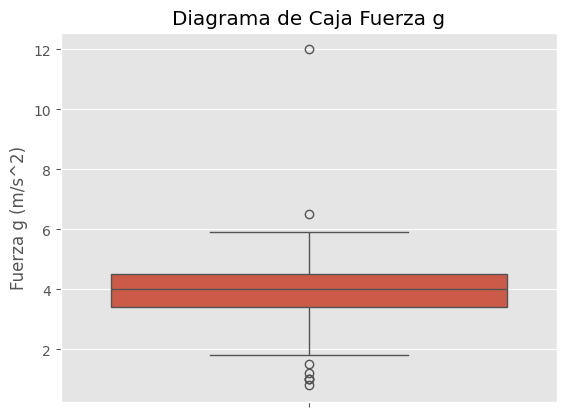

In [56]:
sns.boxplot(data=dfn['Fuerza_g'])
plt.title('Diagrama de Caja Fuerza g')
plt.ylabel('Fuerza g (m/s^2)')
plt.show()

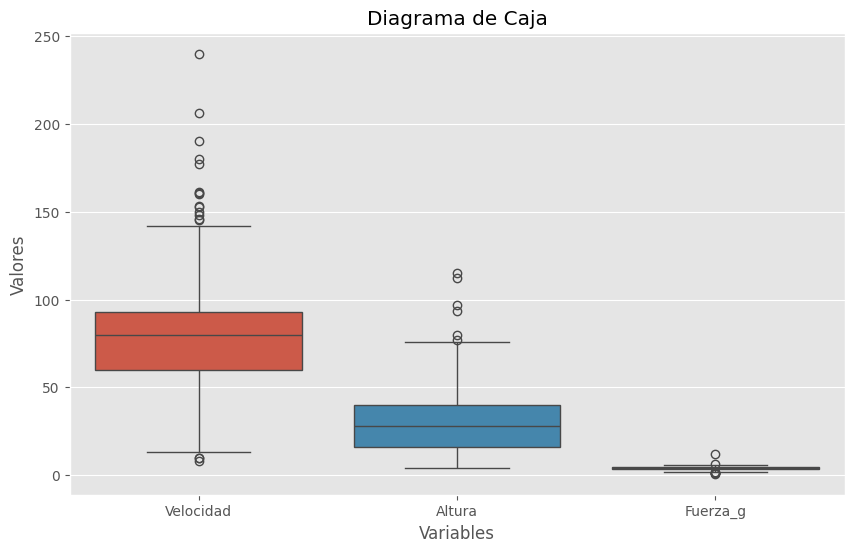

In [57]:
plt.figure(figsize=(10, 6)) 
sns.boxplot(data=dfn)  

plt.title('Diagrama de Caja')  
plt.xlabel('Variables')  
plt.ylabel('Valores')  
plt.show()

# Diagrama de Violín

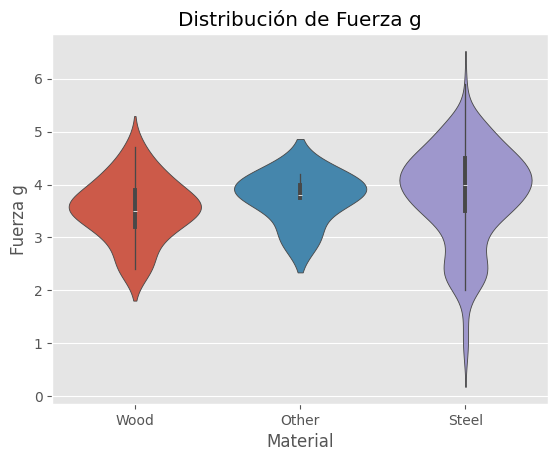

In [58]:
sns.violinplot(x="Material", y="Fuerza_g", data=dfoper, hue='Material')

plt.title('Distribución de Fuerza g')
plt.xlabel('Material')
plt.ylabel('Fuerza g')
plt.show()

$\textbf{Ejercicio}$ Elaborar un gráfico de violín para la variable velocidad.

### Ahora trabajemos con la variable categórica lugar, y suponga que se requiere ubicar los lugares con más montañas rusas. 

In [59]:
dfoper['Ubicación'].value_counts().head(10)

Ubicación
Other                       20
Cedar Point                 15
Six Flags Magic Mountain    15
Canada's Wonderland         14
Kings Island                14
Carowinds                   14
Hersheypark                 12
Alton Towers                10
Knott's Berry Farm           9
Six Flags Over Georgia       9
Name: count, dtype: int64

In [60]:
dfubic=dfoper.query('Ubicación!="Other"')

In [61]:
dfubic['Ubicación'].value_counts()

Ubicación
Cedar Point                 15
Six Flags Magic Mountain    15
Canada's Wonderland         14
Kings Island                14
Carowinds                   14
                            ..
Futuroscope                  1
Bellewaerde                  1
Clacton Pier                 1
Paultons Park                1
Plopsaland De Panne          1
Name: count, Length: 221, dtype: int64

In [62]:
dfubic['Ubicación'].value_counts().head()

Ubicación
Cedar Point                 15
Six Flags Magic Mountain    15
Canada's Wonderland         14
Kings Island                14
Carowinds                   14
Name: count, dtype: int64

Text(0, 0.5, 'Ubicación')

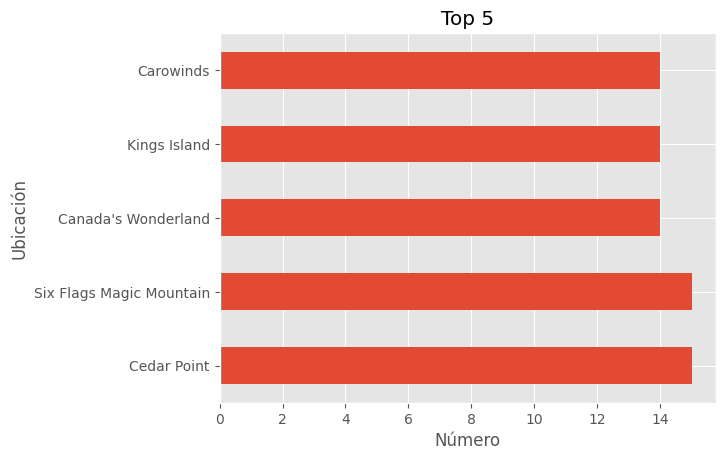

In [63]:
ax=dfubic['Ubicación'].value_counts().head().plot(kind='barh', title='Top 5')
ax.set_xlabel('Número')
ax.set_ylabel('Ubicación')

<Axes: xlabel='Velocidad', ylabel='Count'>

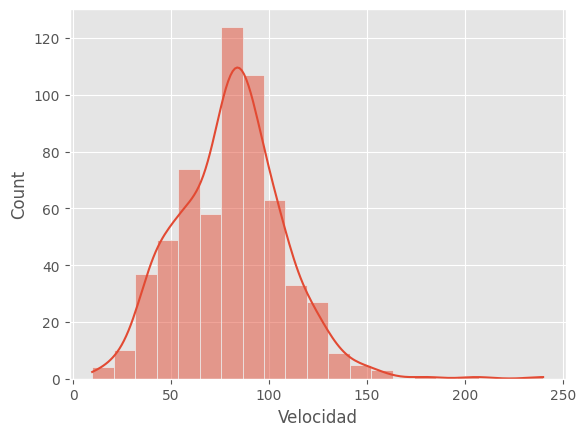

In [64]:
sns.histplot(dfoper['Velocidad'], bins='scott', kde=True)

### En el caso de comparar dos variables podemos optar por un gráfico de dispersión, también conocido como diagrama de dispersión o gráfico de puntos. Este tipo de visualización representa los valores de dos variables en un plano cartesiano, donde cada punto de datos corresponde a una observación en el conjunto de datos respectivo.  

In [65]:
dfna=dfoper.dropna()

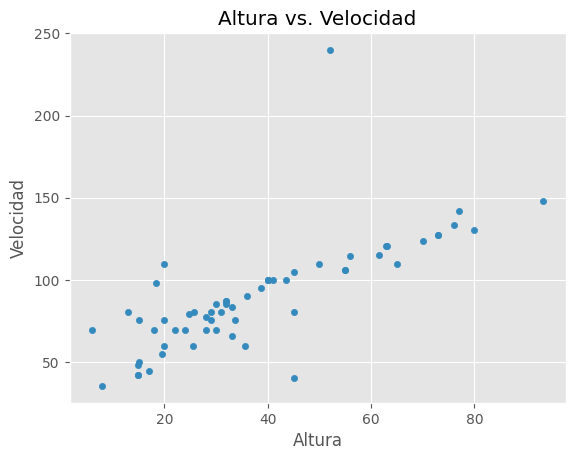

In [66]:
dfna.plot(kind='scatter',
        x='Altura',
        y='Velocidad',
        title='Altura vs. Velocidad')
plt.show()

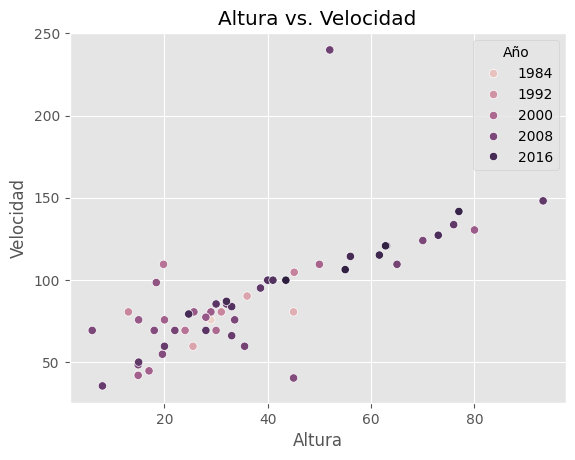

In [67]:
ax = sns.scatterplot(x='Altura',
        y='Velocidad',
        hue='Año',
        data=dfna)
ax.set_title('Altura vs. Velocidad')
plt.show()

In [68]:
np.max(dfna['Velocidad'])

np.float64(239.95259399999998)

In [69]:
dfoper.query('Velocidad==239.95259399999998')

,Nombre,Ubicación,Estado,Velocidad,Altura,Fuerza_g,Material,Año
812,Formula Rossa,Ferrari World Abu Dhabi,Operating,239.952594,51.99888,4.8,Steel,2010


$\textbf{Ejercicio}$ Elaborar un diagrama de disperción (scatter) para las variables Altura y Fuerza g.

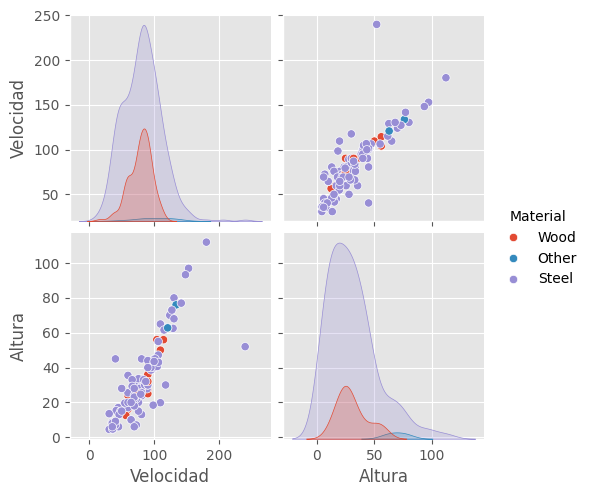

In [70]:
sns.pairplot(dfoper,
             vars=['Velocidad',
                   'Altura'],
            hue='Material')
plt.show()

In [71]:
df_numer = dfoper[['Altura', 'Velocidad', 'Fuerza_g']].dropna()

In [72]:
df_corr=df_numer.corr()
df_corr

,Altura,Velocidad,Fuerza_g
Altura,1.000000,0.739462,0.507628
Velocidad,0.739462,1.000000,0.597028
Fuerza_g,0.507628,0.597028,1.000000


<Axes: >

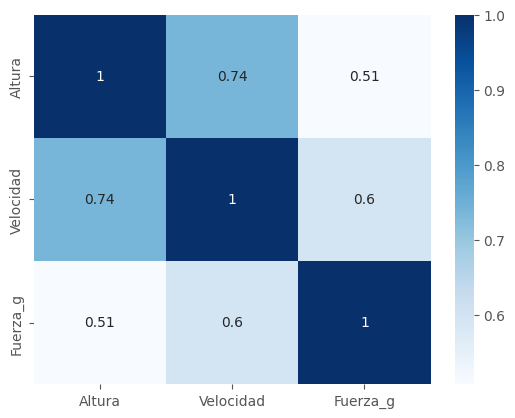

In [73]:
sns.heatmap(df_corr, annot=True, cmap="Blues")

In [74]:
dfc.duplicated().sum()

np.int64(0)

In [75]:
dfc.loc[dfc.duplicated(subset=['Nombre'])].head(10)

,Nombre,Ubicación,Estado,Velocidad,Altura,Fuerza_g,Material,Año
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,97.0000,NaN,4.0,Wood,1927
60,Derby Racer,Revere Beach,Removed,NaN,NaN,NaN,Wood,1937
61,Blue Streak (Conneaut Lake),Conneaut Lake Park,Closed,80.0000,NaN,NaN,Wood,1938
167,Big Thunder Mountain Railroad,Other,NaN,56.0000,NaN,NaN,Steel,1980
237,Thunder Run (Canada's Wonderland),Canada's Wonderland,Operating,64.3736,9.99744,NaN,Steel,1986
239,La Vibora,Other,NaN,51.0000,NaN,NaN,Steel,1986
241,Big Thunder Mountain Railroad,Other,NaN,56.0000,NaN,NaN,Steel,1987
252,La Vibora,Other,NaN,51.0000,NaN,NaN,Steel,1987
262,Flashback (Six Flags Magic Mountain),Other,NaN,56.0000,NaN,3.0,Steel,1988
270,Alpine Bobsled,Other,NaN,56.0000,NaN,NaN,Steel,1989


### Ejercicio: Que no haya nombres repetidos en la base de datos. Dejar el año más actual de operación.